#Arquivo criado para hospedar os códigos e respostas das perguntas 1 a 10 do arquivo "perguntas_sql.md" em Python.

**#Primeiro passo**: importação das bases de dados do GCP.

In [ ]:
import basedosdados as bd
import pandas as pd

PROJECT_ID = "desafio-empm-ulisses-gomes" 

print("Baixando dados do GCP")

# Baixando as tabelas 'dados_mestres_bairro' e 'turismo_fluxo_visitantes.rede_hoteleira_ocupacao_eventos'.
df_bairros = bd.read_sql("SELECT * FROM `datario.dados_mestres.bairro`", billing_project_id=PROJECT_ID)
df_eventos = bd.read_sql("SELECT * FROM `datario.turismo_fluxo_visitantes.rede_hoteleira_ocupacao_eventos`", billing_project_id=PROJECT_ID)

#Baixando a tabela 'adm_central_atendimento_1746.chamado' com o filtros para não exceder a cota de consultas.
#Para as perguntas de 1 a 5, baixamos apenas os chamados do dia 01/04/2023
query_p1 = "SELECT * FROM `datario.adm_central_atendimento_1746.chamado` WHERE DATE(data_inicio) = '2023-04-01'"
df_chamados_p1 = bd.read_sql(query_p1, billing_project_id=PROJECT_ID)
#Para as perguntas 6 a 10, baixamos apenas os chamados de Perturbação do Sossego entre 2022 e 2024.
query_p2 = """
SELECT * FROM `datario.adm_central_atendimento_1746.chamado` 
WHERE id_subtipo = '5071' AND DATE(data_inicio) BETWEEN '2022-01-01' AND '2024-12-31'
"""
df_chamados_p2 = bd.read_sql(query_p2, billing_project_id=PROJECT_ID)

#Transformando as colunas de datas para o formato 'datetime.date' do pandas.
df_chamados_p2['data_inicio'] = pd.to_datetime(df_chamados_p2['data_inicio']).dt.date
df_eventos['data_inicial'] = pd.to_datetime(df_eventos['data_inicial']).dt.date
df_eventos['data_final'] = pd.to_datetime(df_eventos['data_final']).dt.date

print("Bases carregadas")

Baixando dados do GCP
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Bases carregadas


**#PERGUNTA 1**- Quantos chamados foram registrados no dia 01/04/2023?

In [ ]:
#Objetivo do código, aplicar 'len' para contar o número de chamados registrados no dia 01/04/2023.
q1_resposta = len(df_chamados_p1)
print(f"Resposta: foram registrados {q1_resposta} chamados em 01/04/2023:")

Resposta: Total de chamados no dia 01/04/2023: 2067


**#PERGUNTA 2**- Qual foi o bairro com o maior número de chamados registrados no dia 01/04/2023?

In [6]:
# Objetivo da código: aplicar 'valuecounts e 'idxmax' para contar os chamados e retornar apenas o chamado mais registrado
q2_resposta = df_chamados_p1['tipo'].value_counts().idxmax()
print(f"Resposta: o chamado mais registrado foi o de '{q2_resposta}'")

Resposta: o chamado mais registrado foi o de 'Estacionamento irregular'


#Mesclagem 'merge' das tabelas 'dados_mestres_bairro' e 'adm_central_atendimento_1746.chamado'

In [8]:
df_merged_p1 = df_chamados_p1.merge(df_bairros, on='id_bairro', how='left')
print("Mesclagem executada")

Mesclagem executada


**#PERGUNTA 3**- Quais os nomes dos 3 bairros que mais tiveram chamados abertos nesse dia?

In [18]:
#objetivo do código: aplicar 'valuecounts' para contar os chamados por bairro e 'head(3)' para retornar apenas os 3 maiores.
q3_resposta = df_merged_p1['nome'].value_counts().head(3) #Retorna apenas os 3 bairros geo-referenciados nas reclamações com mais chamados registrados.
print("\n" + "-" * 50)
print("RESULTADO: TOP 3 BAIRROS")
print("-" * 50)
for posicao, (bairro, quantidade) in enumerate(q3_resposta.items(), start=1): #Itera por meio do 'enumerate' sobre os bairros e suas respectivas quantidades, formatando a saída para exibir a posição, nome do bairro e quantidade de chamados.
    print(f" {posicao}º Lugar | {bairro.ljust(25)} | {quantidade} chamados")

print("-" * 50 + "\n")


--------------------------------------------------
RESULTADO: TOP 3 BAIRROS
--------------------------------------------------
 1º Lugar | Campo Grande              | 125 chamados
 2º Lugar | Tijuca                    | 100 chamados
 3º Lugar | Barra da Tijuca           | 62 chamados
--------------------------------------------------



**Observação** Como descobrimos na nossa exploração inicial em SQL (Pergunta 3 e 5), existem chamados no sistema 1746 que não possuem um 'id_bairro' associado. Geralmente, são serviços atrelados a entidades móveis (como reclamações de linhas de Ônibus ou BRT) ou serviços digitais, que não possuem geolocalização fixa. 

Como a função 'value_counts()' tem como parâmetro o 'dropna=True', que desconsidera os valores nulos, optou-se aqui pelo uso dessa função e assim não evidenciar as reclamações não geolocalizadas, como foi evidenciado na consulta SQL.

**PERGUNTA 4**- Qual o nome da subprefeitura com mais chamados abertos nesse dia?

In [ ]:
#Objetivo do código: aplicar 'valuecounts' para contar os chamados por subprefeitura e 'idxmax' para retornar apenas a subprefeitura com mais chamados registrados.
q4_resposta = df_merged_p1['subprefeitura'].value_counts().idxmax()
print(f"\nResposta: A subprefeitura com mais chamados foi a '{q4_resposta}'")


Resposta: A subprefeitura com mais chamados foi a 'Subprefeitura da Zona Norte'


**PERGUNTA 5:** - Existe algum chamado aberto nesse dia que não foi associado a um bairro ou subprefeitura na tabela de bairros? Se sim, por que isso acontece?

In [ ]:
#Objetivo do código: aplicar 'isnull' para identificar os chamados sem bairro associado e 'len' para contar quantos são.
chamados_sem_bairro = df_merged_p1[df_merged_p1['id_bairro'].isnull()]
print(f"\nResultado: Sim, existem {len(chamados_sem_bairro)} chamados sem bairro associado.")
print("Motivação:Ao analisar a consulta, observa-se que esses chamados se referem a trasnportes como 'Veículos' e /ou 'BRT (corredor expresso de ônibus)' - de maneira similar a pergunta 3 - 'Fiscalização Eletrônica' e 'Ouvidoria - CLF'")


Resultado: Sim, existem 260 chamados sem bairro associado.
Motivação:Ao analisar a consulta, observa-se que esses chamados se referem a trasnportes como 'Veículos' e /ou 'BRT (corredor expresso de ônibus)' - de maneira similar a pergunta 3 - 'Fiscalização Eletrônica' e 'Ouvidoria - CLF'


**PERGUNTA 6**- Quantos chamados de Perturbação do sossego foram abertos nesse período (01/01/2022 a 31/12/2024)?

In [34]:
#Objetivo do código: aplicar 'len' para contar o número de chamados de perturbação do sossego registrados entre 2022 e 2024.
q6_resposta = len(df_chamados_p2)
print(f"Resultado:Total de chamados de perturbação do sossego (2022-2024): {q6_resposta} chamados")

Resultado:Total de chamados de perturbação do sossego (2022-2024): 57532 chamados


**PERGUNTA 7**-Selecione os chamados com esse subtipo que foram abertos durante os eventos contidos na tabela de eventos (Reveillon, Carnaval e Rock in Rio).

In [35]:
df_cross = df_chamados_p2.merge(df_eventos, how='cross')
df_chamados_eventos = df_cross[(df_cross['data_inicio'] >= df_cross['data_inicial']) & 
                               (df_cross['data_inicio'] <= df_cross['data_final'])]

print("\nResultado:Tabela de chamados durante eventos gerada com sucesso. Total de linhas:", len(df_chamados_eventos))


Resultado:Tabela de chamados durante eventos gerada com sucesso. Total de linhas: 1365


**PERGUNTA 8**-Quantos chamados desse subtipo foram abertos em cada evento?

In [36]:
#Etapa intermediária: importando a biblioteca 'matplotlib' para visualização de dados.
import matplotlib.pyplot as plt

In [41]:
#Calculando o valor solicitado: o total de chamados de perturbação do sossego durante cada evento.
q8_resposta = df_chamados_eventos['evento'].value_counts()
print("\nResposta:Chamados por Evento:")
display(q8_resposta)


Resposta:Chamados por Evento:


evento
Rock in Rio    958
Carnaval       255
Réveillon      152
Name: count, dtype: int64

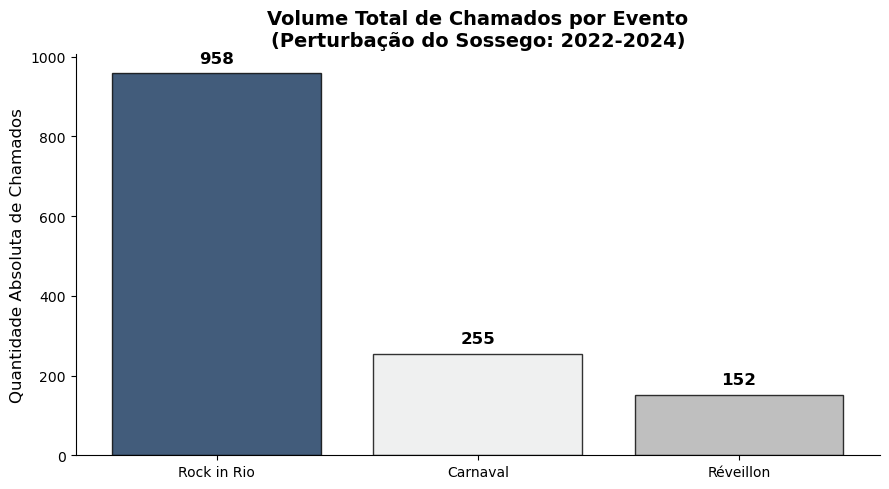

In [49]:
#Objetivo do código: extrair os eventos e as quantidades de chamados para listas separadas, e monstar um gráfico com 'matplotlib.pyplot'.
eventos = q8_resposta.index.tolist() #extrai os eventos e as quantidades de chamados para listas separadas, facilitando a construção do gráfico.
total_chamados = q8_resposta.values.tolist()
plt.figure(figsize=(9, 5))#configura o tamanho da figura
#adicionando cores personalizadas presentes no manual de marca da prefeitura do Rio de Janeiro.
cores_eventos = ['#13335a','#eceded','#b0b0b0']#azul escuro, cinza claro e cinza escuro para destacar o maior valor de chamados
barras = plt.bar(eventos, total_chamados, color=cores_eventos, edgecolor='black', alpha=0.8)
plt.title('Volume Total de Chamados por Evento\n(Perturbação do Sossego: 2022-2024)', fontsize=14, fontweight='bold')#Adiciona títulos e rótulos aos eixos
plt.ylabel('Quantidade Absoluta de Chamados', fontsize=12)
#calcula uma posição para os rótulos de dados para evitar sobreposição de barras
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + (max(total_chamados) * 0.02),
             f'{int(altura)}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.gca().spines['top'].set_visible(False)#Remoção a borda superior da figura
plt.gca().spines['right'].set_visible(False)
#Exibição do resultado
plt.tight_layout()
plt.show()

**Observação:** Como pode ser observado no gráfico acima, O Rock in Rio é o evento que mais distoa dos demais com reclamações de perrturbação do sossego necessitando então de um maior incremento a fiscalização desse tipo de chamado nas datas desse evento

**PERGUNTA 9**-Qual evento teve a maior média diária de chamados abertos desse subtipo?

In [51]:
#objetivo do código: calcular a média diária de chamados para cada evento, considerando a duração de cada evento.
df_eventos['dias_duracao'] = (df_eventos['data_final'] - df_eventos['data_inicial']).apply(lambda x: x.days) + 1 #calcula a duração de cada evento em dias, adicionando 1 para incluir o dia inicial.

chamados_por_evento = df_chamados_eventos.groupby('evento').size().reset_index(name='total_chamados')#agrupa os chamados por evento e conta o total de chamados para cada um, resultando em um DataFrame com as colunas 'evento' e 'total_chamados'.

df_medias_eventos = chamados_por_evento.merge(df_eventos[['evento', 'dias_duracao']], on='evento') #mescla o resultado do agrupamento com a tabela de eventos para obter a duração de cada evento ao lado do total de chamados.
df_medias_eventos['media_diaria'] = df_medias_eventos['total_chamados'] / df_medias_eventos['dias_duracao'] 

campeao_media = df_medias_eventos.sort_values(by='media_diaria', ascending=False).iloc[0] #ordena os eventos pela média diária de chamados em ordem decrescente e seleciona a maior média.
print(f"\nResultado: O evento com maior média diária foi o {campeao_media['evento']} com {campeao_media['media_diaria']:.2f} chamados/dia.")


Resultado: O evento com maior média diária foi o Rock in Rio com 319.33 chamados/dia.


**PERGUNTA 10**-Compare as médias diárias de chamados abertos desse subtipo durante os eventos específicos (Reveillon, Carnaval e Rock in Rio) e a média diária de chamados abertos desse subtipo considerando todo o período de 01/01/2022 até 31/12/2024.

In [ ]:
#Objetivo do código: calcular a média diária de chamados para cada evento, considerando a duração de cada evento, e comparar com a média geral de chamados por dia no período de 2022 a 2024.
import pandas as pd
import matplotlib.pyplot as plt

# Calculando a Média Geral (1096 dias)

dias_totais = 1096

media_geral = len(df_chamados_p2) / dias_totais



# Criando uma coluna com o Ano do evento para facilitar a identificação da edição

df_eventos['ano'] = pd.to_datetime(df_eventos['data_inicial']).dt.year

df_eventos['nome_edicao'] = df_eventos['evento'] + ' ' + df_eventos['ano'].astype(str)

df_eventos['dias_duracao'] = (pd.to_datetime(df_eventos['data_final']) - pd.to_datetime(df_eventos['data_inicial'])).dt.days + 1



# Cruzando novamente chamados com a tabela de eventos atualizada

df_cross = df_chamados_p2.merge(df_eventos, how='cross')

df_chamados_eventos = df_cross[(df_cross['data_inicio'] >= df_cross['data_inicial']) &

                               (df_cross['data_inicio'] <= df_cross['data_final'])]



# ==============================================================================

# 2. DATAFRAME: MÉDIA CONSOLIDADA POR EVENTO (Ex: Carnaval)

# ==============================================================================

# Somamos todos os chamados e todos os dias de cada evento

df_consolidado = df_edicoes.groupby('evento').agg(

    chamados_totais=('total_chamados', 'sum'),

    dias_totais=('dias_duracao', 'sum')

).reset_index()



df_consolidado['media_diaria'] = round(df_consolidado['chamados_totais'] / df_consolidado['dias_totais'], 2)

df_consolidado['media_geral_3anos'] = round(media_geral, 2)

df_consolidado = df_consolidado.sort_values('media_diaria', ascending=True) # Ordena para o gráfico ficar bonito



print("\n" + "_"*53)

print("MÉDIA DIÁRIA POR EVENTO VS MÉDIA GERAL")

print("_"*53)

print(df_consolidado[['evento', 'media_diaria', 'media_geral_3anos']].to_string(index=False))








_____________________________________________________
MÉDIA DIÁRIA POR EVENTO VS MÉDIA GERAL
_____________________________________________________
     evento  media_diaria  media_geral_3anos
  Réveillon         50.67              52.49
   Carnaval         63.75              52.49
Rock in Rio        273.71              52.49


     evento  media_diaria_evento  media_diaria_geral
Rock in Rio               136.86               52.49
   Carnaval                63.75               52.49
  Réveillon                50.67               52.49


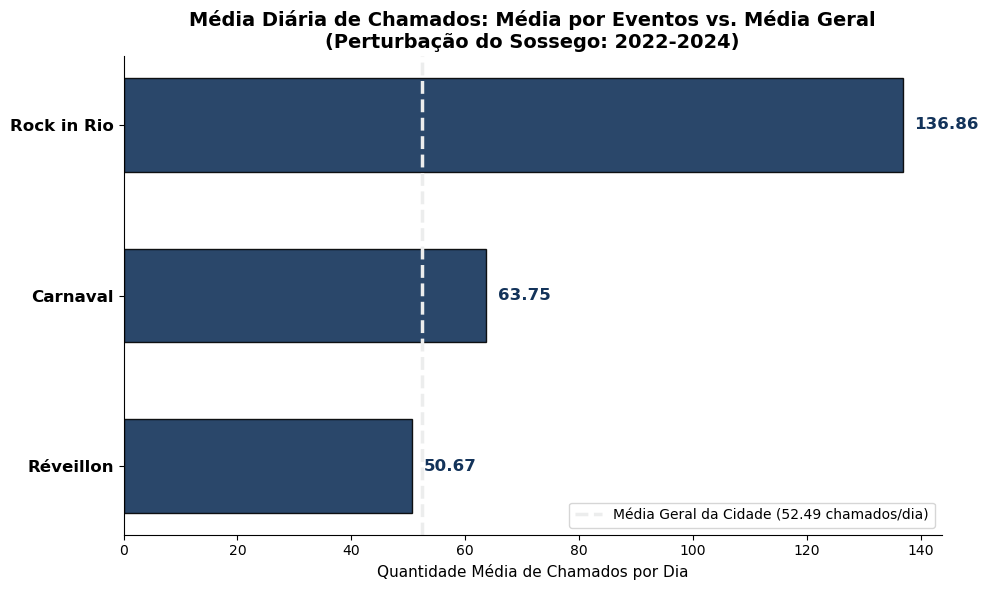

In [92]:
#Objetivo do código: calcular a média diária de chamados para cada evento, considerando a duração de cada evento, e comparar com a média geral de chamados por dia no período de 2022 a 2024.
import pandas as pd

df_chamados_p2 = df_chamados_p2.copy()
df_eventos = df_eventos.copy()

df_chamados_p2["data_inicio"] = pd.to_datetime(df_chamados_p2["data_inicio"]).dt.date
df_eventos["data_inicial"] = pd.to_datetime(df_eventos["data_inicial"]).dt.date
df_eventos["data_final"]   = pd.to_datetime(df_eventos["data_final"]).dt.date


eventos_alvo = ["Rock in Rio", "Carnaval", "Réveillon"] #filtrando apenas os eventos de interesse para a análise

df_chamados_p2 = df_chamados_p2[
    (df_chamados_p2["id_subtipo"] == "5071") &
    (df_chamados_p2["data_inicio"] >= pd.to_datetime("2022-01-01").date()) &
    (df_chamados_p2["data_inicio"] <= pd.to_datetime("2024-12-31").date())
].copy()

df_eventos = df_eventos[df_eventos["evento"].isin(eventos_alvo)].copy()

df_eventos = df_eventos.drop_duplicates(subset=["evento", "data_inicial", "data_final"]) #exclui duplicatas caso existam

df_eventos["dias_duracao"] =((pd.to_datetime(df_eventos["data_final"]) - pd.to_datetime(df_eventos["data_inicial"])).dt.days + 1) #calcula a duração de cada evento em dias, adicionando 1 para incluir o dia inicial.


df_chamados_p2["_k"] = 1 #cria uma coluna auxiliar para realizar o 'cross join' entre chamados e eventos, permitindo comparar cada chamado por evento.
df_eventos["_k"] = 1

df_cross = df_chamados_p2.merge(df_eventos, on="_k", how="inner").drop(columns="_k")

df_chamados_eventos = df_cross[
    (df_cross["data_inicio"] >= df_cross["data_inicial"]) &
    (df_cross["data_inicio"] <= df_cross["data_final"])
].copy()

df_edicoes = df_chamados_eventos.groupby(
    ["evento", "data_inicial", "data_final", "dias_duracao"],
    as_index=False
).agg(
    total_chamados=("id_chamado", "count")
)

df_consolidado = df_edicoes.groupby("evento", as_index=False).agg( #calcula a média consolidada por evento
    chamados_totais=("total_chamados", "sum"),
    dias_totais=("dias_duracao", "sum")
)

df_consolidado["media_diaria_evento"] = (df_consolidado["chamados_totais"] / df_consolidado["dias_totais"]).round(2)


dias_totais_periodo = 1096 #calcula a média geral final
media_geral = (len(df_chamados_p2) / dias_totais_periodo)

df_consolidado["media_diaria_geral"] = round(media_geral, 2)


df_consolidado = df_consolidado.sort_values("media_diaria_evento", ascending=False) #ordena a disposição da análise no dataframe

print(df_consolidado[["evento", "media_diaria_evento", "media_diaria_geral"]].to_string(index=False))

import matplotlib.pyplot as plt #montando g´rafico com 'matplotlib.pyplot' para melhor visualziação dos resultados

fig, ax = plt.subplots(figsize=(10, 6)) 

df_plot = df_consolidado.sort_values("media_diaria_evento", ascending=True) #ordenando os dados para que o gráfico fique mais intuitivo, com a barra de maior média no topo.

eventos = df_plot['evento'].tolist()
medias_eventos = df_plot['media_diaria_evento'].tolist()

barras_evento = ax.barh(eventos, medias_eventos, color='#13335a', height=0.55, edgecolor='black', alpha=0.9)

ax.axvline(x=media_geral, color='#eceded', linestyle='--', linewidth=2.5, 
           label=f'Média Geral da Cidade ({media_geral:.2f} chamados/dia)')

for barra in barras_evento: #adicionando rótulos de dados
    largura = barra.get_width()
    ax.text(largura + 2, barra.get_y() + barra.get_height()/2, 
            f'{largura:.2f}', 
            va='center', ha='left', fontsize=12, fontweight='bold', color='#13335a')

ax.set_yticklabels(eventos, fontsize=12, fontweight='bold')
ax.set_title('Média Diária de Chamados: Média por Eventos vs. Média Geral\n(Perturbação do Sossego: 2022-2024)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Quantidade Média de Chamados por Dia', fontsize=11)

ax.spines['top'].set_visible(False) #diminuindo o excesso de recursos gráficos e saturação para melhorar a visualização dos dados
ax.spines['right'].set_visible(False)

ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Observação:** A análise do resultado da Pergunta 10, visualizadas no dataframe e no gráfico acima, indica que os eventos com maior média diária de reclamações superaram a média diária do período analisado. O Rock in Rio registrou uma média de 136,86 chamados por dia (mais de 2,5 vezes a média diária geral para esse subtipo de chamado no período observado). 
O Carnaval registrou uma média de 63,75 chamados por dia, valor acima da média diária calculada ao longo dos 3 anos. Com isso, observamos o potencial que ambos os eventos (Rock in Rio e Carnaval) têm de impactar negativamente a vida dos cidadãos cariocas. 
Além disso, o Réveillon, com uma média de 50,67 chamados por dia, foi o único com média diária ligeiramente abaixo da média global do período (52,49), ainda que permaneça em patamar elevado. 
Portanto, recomenda-se a ampla divulgação do serviço de fiscalização de perturbação do sossego, por meio da Central de Atendimento 1746, antes e durante esses eventos, especialmente no Carnaval e no Rock in Rio. 
Essa divulgação deve ser intensificada em mídias tradicionais, como rádio e TV aberta, e também em canais digitais e redes sociais, incluindo a página oficial da Prefeitura e a republicação por perfis institucionais de grande alcance, como o COR-Rio no Instagram, que possui elevado engajamento e frequente acompanhamento junto à população carioca. 
De forma complementar, recomenda-se a suplementação e maior integração estratégica entre as equipes de fiscalização e as responsáveis pelo tratamento e encaminhamento dos chamados durante esses eventos, com o objetivo de ampliar a eficiência operacional, reduzir o tempo de resposta e qualificar o atendimento à população.